#### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#### Data Import

In [3]:
m_data = pd.read_excel("Data/Marketing_data.xlsx", sheet_name = "Marketing_data", index_col= "ID")
m_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
ID,,,,,,,,,,,,,,,,,,,,,
737,1949,PhD,Married,"$80,360.00",0,0,2013-03-03 00:00:00,56,1493,86,...,5,2,0,1,1,1,0,0,0,SP
3174,1959,Graduation,Together,"$87,771.00",0,1,5/22/13,61,1492,38,...,4,6,0,1,1,1,1,1,0,SP
5536,1959,Graduation,Together,"$87,771.00",0,1,5/22/13,61,1492,38,...,4,6,0,1,1,1,1,1,0,CA
1103,1976,Master,Married,"$81,929.00",1,0,9/29/12,60,1486,55,...,10,6,1,0,1,0,0,1,0,AUS
5547,1982,PhD,Married,"$84,169.00",0,0,2013-07-08 00:00:00,9,1478,19,...,6,3,0,1,1,0,0,1,0,SP


## 1. Exploratory Data Analysis (E.D.A)

In [4]:
m_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 737 to 10364
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Year_Birth           2240 non-null   int64 
 1   Education            2240 non-null   object
 2   Marital_Status       2240 non-null   object
 3    Income              2216 non-null   object
 4   Kidhome              2240 non-null   int64 
 5   Teenhome             2240 non-null   int64 
 6   Dt_Customer          2240 non-null   object
 7   Recency              2240 non-null   int64 
 8   MntWines             2240 non-null   int64 
 9   MntFruits            2240 non-null   int64 
 10  MntMeatProducts      2240 non-null   int64 
 11  MntFishProducts      2240 non-null   int64 
 12  MntSweetProducts     2240 non-null   int64 
 13  MntGoldProds         2240 non-null   int64 
 14  NumDealsPurchases    2240 non-null   int64 
 15  NumWebPurchases      2240 non-null   int64 
 16  NumCatal

Variable income is an object, which has blank values. So, it is required fill the missing values through imputation.

In [5]:
m_data.describe(include = 'all')

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
count,2240.000000,2240,2240,2216,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240
unique,NaN,5,8,1974,NaN,NaN,663,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
top,NaN,Graduation,Married,"$7,500.00",NaN,NaN,8/31/12,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP
freq,NaN,1127,864,12,NaN,NaN,12,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1095
mean,1968.805804,NaN,NaN,NaN,0.444196,0.506250,NaN,49.109375,303.935714,26.302232,...,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375,NaN
std,11.984069,NaN,NaN,NaN,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,...,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391,NaN
min,1893.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,1959.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,24.000000,23.750000,1.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,1970.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,49.000000,173.500000,8.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,1977.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,74.000000,504.250000,33.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


### 1.1) Data Cleaning

In [6]:
m_data['Income_Clean']= (m_data[" Income "].str.replace(r"[\$,]","",regex=True).astype(float))
m_data['Income_Clean']

ID
737      80360.0
3174     87771.0
5536     87771.0
1103     81929.0
5547     84169.0
          ...   
9553      7500.0
9617     15033.0
9960     26868.0
10241    11448.0
10364    23295.0
Name: Income_Clean, Length: 2240, dtype: float64

In [7]:
m_data.drop(" Income ", axis = 1,inplace = True)

In [8]:
m_data['Dt_Customer'] = pd.to_datetime(m_data['Dt_Customer'])


#### 1.1.1) Data Imputation

In [9]:
m_data.isnull().sum()

Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
Income_Clean           24
dtype: int64

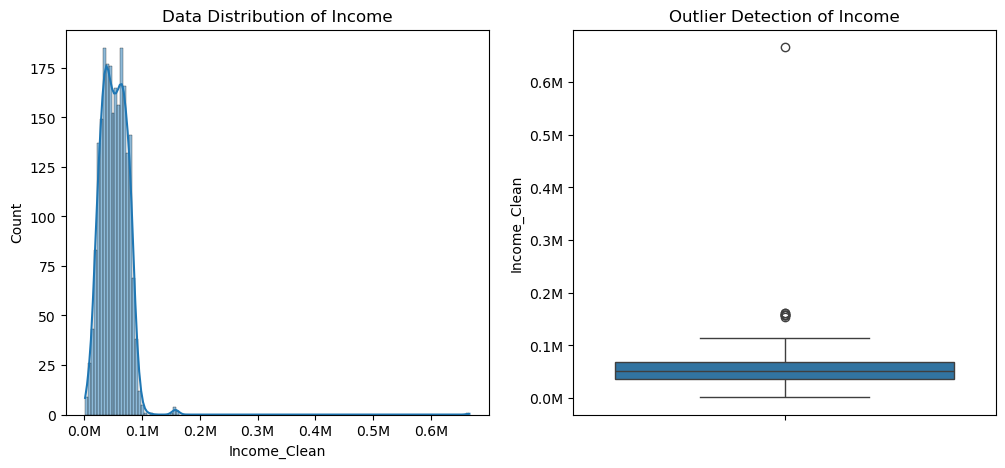

In [10]:
# Checking the distribution and outlier of Income_Clean data
fig,axes = plt.subplots(1,2, figsize=(12,5)) 
axes[0].set_title("Data Distribution of Income")
dist = sns.histplot(data = m_data, x= 'Income_Clean', kde = True, ax= axes[0])
dist.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M'))
axes[1].set_title("Outlier Detection of Income")
out = sns.boxplot(m_data, y='Income_Clean')
out.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{y/1000000:.1f}M'))
plt.savefig("Images/1.Dist_Income.png")


Income is right skewed distribution and it contains outliers. Mean imputation will not be ideal due to it's outlier sensitivity. Hence, proceeding with median imputation of blank values.

In [11]:
# Imputation of Income
m_data['Income_Clean'] = m_data['Income_Clean'].fillna(m_data['Income_Clean'].median())

#### 1.1.2) Outlier Detection of Regressors

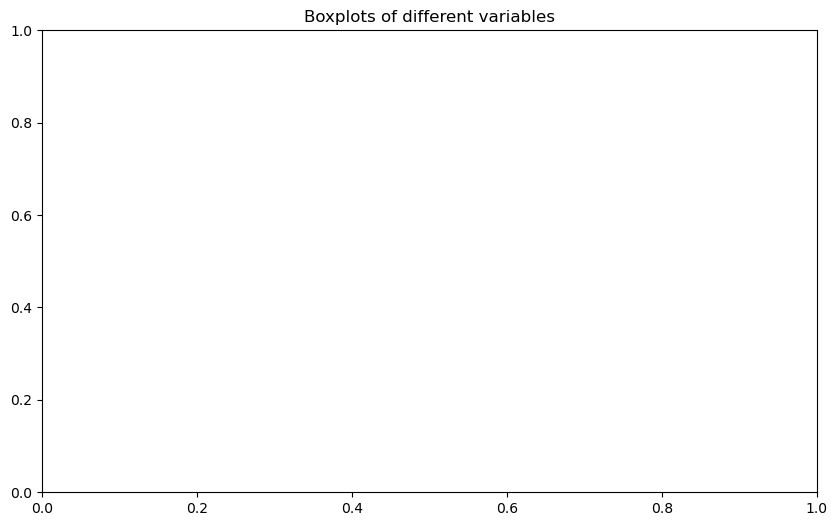

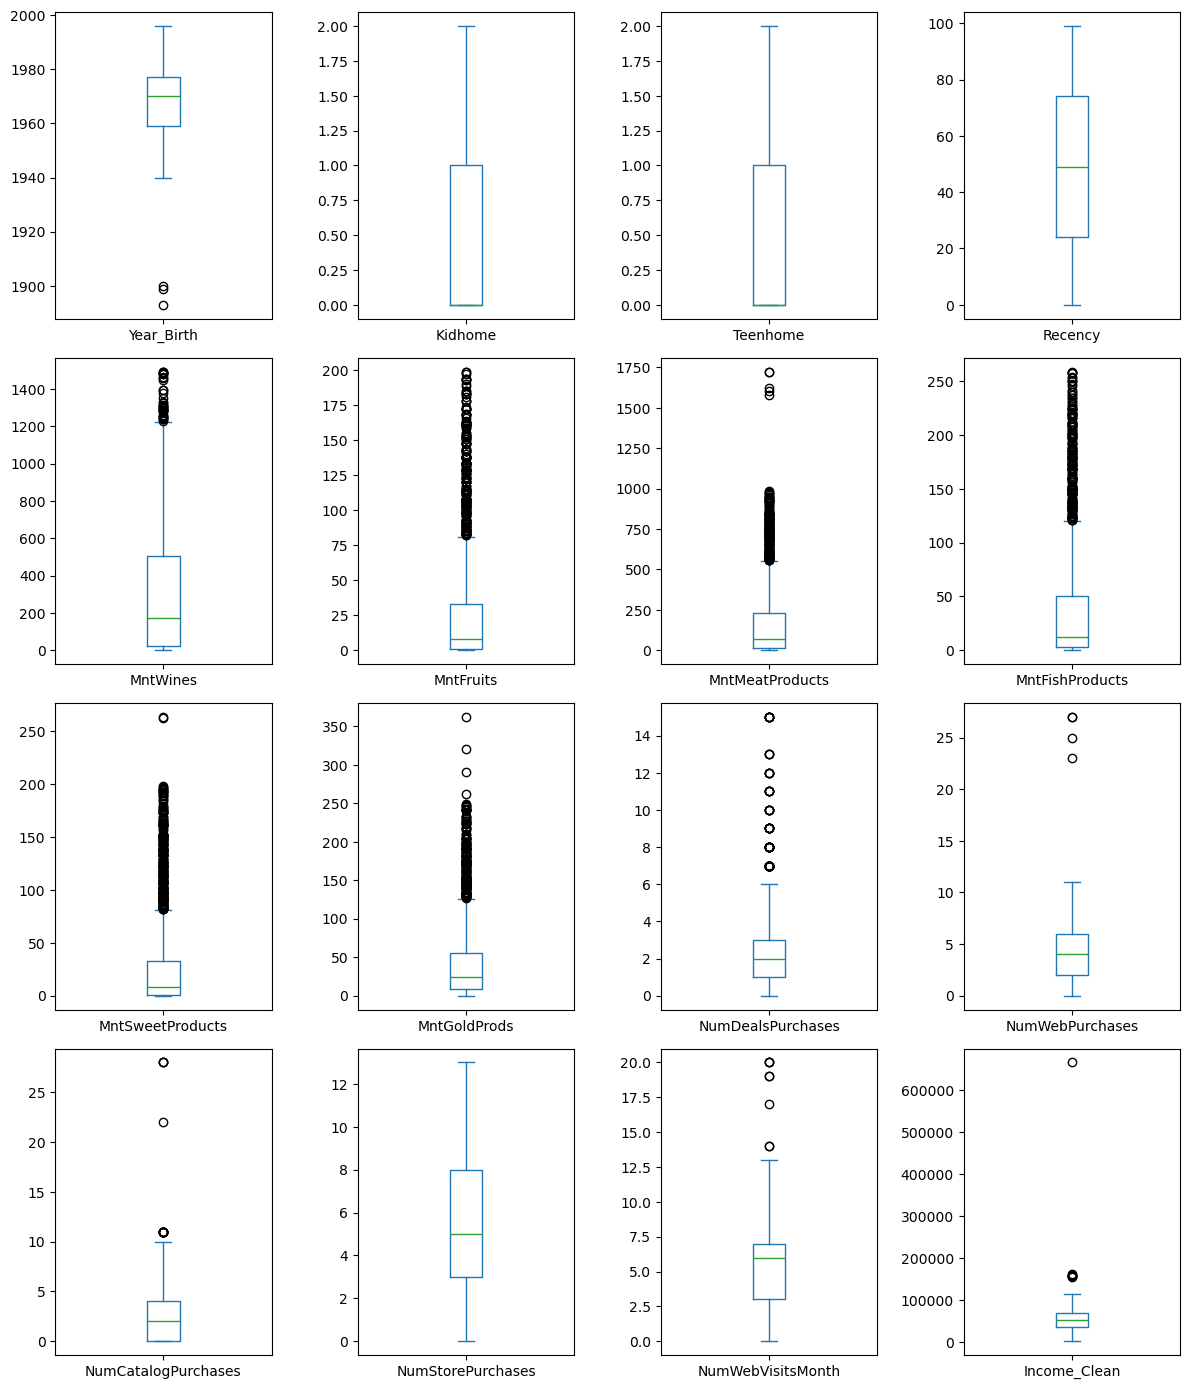

In [12]:
# Removing the indicators and string components from the data.
m_data_outplot = m_data.drop(columns = ['AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
                                        'Response', 'Complain','AcceptedCmp3']).select_dtypes(include= np.number)
plt.figure(figsize = (10,6))
plt.title("Boxplots of different variables")
m_data_outplot.plot(subplots=True, layout=(4,4), kind='box', figsize=(12,14))
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.savefig('Images/Boxplots.png')

The above boxplots represents the presence of outliers among the predictors. Initial visual analysis indicates almost all the variables have outliers except Kidhome, Teenhome, Recency, Store Purchases. But a concrete analysis is required to find the variables with large number of outliers which may potentially distorts the model. One such method is IQR(Interquartile Range).ned'

#### 1.1.2.1) Detection of Outliers through IQR

In [13]:
def outlier_data(a):
        Q1 = m_data_outplot[a].quantile(0.25)
        Q3 = m_data_outplot[a].quantile(0.75)
        IQR = Q3-Q1
        Lower_Bound = Q1-1.5*IQR
        Upper_Bound = Q3+1.5*IQR
        Outliers = len(m_data_outplot[(m_data_outplot[a]<Lower_Bound) | (m_data_outplot[a]>Upper_Bound)])
        Outliers_Pct = Outliers/len(m_data_outplot[a])*100
        return print(f"Lower_Bound of {a}: \n{Lower_Bound:.2f}, \nUpper_Bound of {a}:  \n{Upper_Bound:.2f}, \nNumber of Observations in {a}: \n{Outliers}, \nOutliers_Percentage:\n{Outliers_Pct:.2f}%"
                        )
outlier_data('MntWines')

Lower_Bound of MntWines: 
-697.00, 
Upper_Bound of MntWines:  
1225.00, 
Number of Observations in MntWines: 
35, 
Outliers_Percentage:
1.56%


IQR Method of outlier detection indicates the presence of regressors with relatively large percentage of outliers(>5%). Those includes the purchase of Fruits,Fish,Meat,Sweet and Gold. Hence, a suitable feature transformation is required to scale down their magnitude for further analysis.

### 1.1) Feature Engineering & Feature Transformation

In [14]:
out_var = ['MntFruits','MntFishProducts','MntMeatProducts','MntSweetProducts','MntGoldProds']

In [15]:
def out_trans(a):
        ln_var = np.log1p(m_data[a])
        return m_data.insert(m_data.shape[1],'ln_'+a,ln_var)
out_trans('MntFruits')
out_trans('MntFishProducts')
out_trans('MntMeatProducts')
out_trans('MntSweetProducts')
out_trans('MntGoldProds')


In [16]:
m_data.head()

,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp2,Response,Complain,Country,Income_Clean,ln_MntFruits,ln_MntFishProducts,ln_MntMeatProducts,ln_MntSweetProducts,ln_MntGoldProds
ID,,,,,,,,,,,,,,,,,,,,,
737,1949,PhD,Married,0,0,2013-03-03,56,1493,86,454,...,0,0,0,SP,80360.0,4.465908,4.727388,6.120297,3.784190,3.784190
3174,1959,Graduation,Together,0,1,2013-05-22,61,1492,38,287,...,1,1,0,SP,87771.0,3.663562,3.931826,5.662960,4.060443,3.526361
5536,1959,Graduation,Together,0,1,2013-05-22,61,1492,38,287,...,1,1,0,CA,87771.0,3.663562,3.931826,5.662960,4.060443,3.526361
1103,1976,Master,Married,1,0,2012-09-29,60,1486,55,278,...,0,1,0,AUS,81929.0,4.025352,3.912023,5.631212,0.000000,5.225747
5547,1982,PhD,Married,0,0,2013-07-08,9,1478,19,403,...,0,1,0,SP,84169.0,2.995732,0.000000,6.001415,2.995732,0.000000


In [17]:
m_data['Total Purchase'] = m_data['NumCatalogPurchases']+m_data['NumWebPurchases']+m_data['NumDealsPurchases']+m_data['NumStorePurchases']
m_data['Campaign Success'] = m_data['AcceptedCmp1']+m_data['AcceptedCmp2']+m_data['AcceptedCmp3']+m_data['AcceptedCmp4']+m_data['AcceptedCmp5']+m_data['Response']

In [18]:
#Label Transformations
m_data['Married_PhD'] = np.where((m_data['Marital_Status']=='Married')&(m_data['Education']=='PhD'),1,0)

In [19]:
m_data['Education_Levels'] = m_data['Education'].map({'Basic':0, '2n Cycle':1, 'Graduation':2, 'Master':3,'PhD':4})

In [20]:
# The categorical labels are provided based on the Store, Web , Catalog, Deals purchases
m_data['Marital_Status'] = m_data['Marital_Status'].map({'Absurd':0, 'Alone':2, 'Divorced':4 ,'Married':7, 'Single':5, 'Together':6 ,'Widow':3, 'YOLO':1})

In [21]:
#One-hot encoding to understand the geographical impacts
countries = pd.get_dummies(m_data['Country'],drop_first = True, dtype = int)
countries

,CA,GER,IND,ME,SA,SP,US
ID,,,,,,,
737,0,0,0,0,0,1,0
3174,0,0,0,0,0,1,0
5536,1,0,0,0,0,0,0
1103,0,0,0,0,0,0,0
5547,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...
9553,0,0,1,0,0,0,0
9617,0,0,0,0,1,0,0
9960,0,0,0,0,1,0,0


In [22]:
m_data = pd.concat([m_data,countries], axis = 1,)
m_data

,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Campaign Success,Married_PhD,Education_Levels,CA,GER,IND,ME,SA,SP,US
ID,,,,,,,,,,,,,,,,,,,,,
737,1949,PhD,7,0,0,2013-03-03,56,1493,86,454,...,3,1,4,0,0,0,0,0,1,0
3174,1959,Graduation,6,0,1,2013-05-22,61,1492,38,287,...,5,0,2,0,0,0,0,0,1,0
5536,1959,Graduation,6,0,1,2013-05-22,61,1492,38,287,...,5,0,2,1,0,0,0,0,0,0
1103,1976,Master,7,1,0,2012-09-29,60,1486,55,278,...,3,0,3,0,0,0,0,0,0,0
5547,1982,PhD,7,0,0,2013-07-08,9,1478,19,403,...,3,1,4,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9553,1987,Graduation,7,0,0,2013-09-01,94,0,2,3,...,0,0,2,0,0,1,0,0,0,0
9617,1951,Graduation,5,0,0,2014-04-16,37,0,4,5,...,0,0,2,0,0,0,0,1,0,0
9960,1991,Basic,5,1,0,2014-04-30,52,0,0,1,...,0,0,0,0,0,0,0,1,0,0


<Axes: >

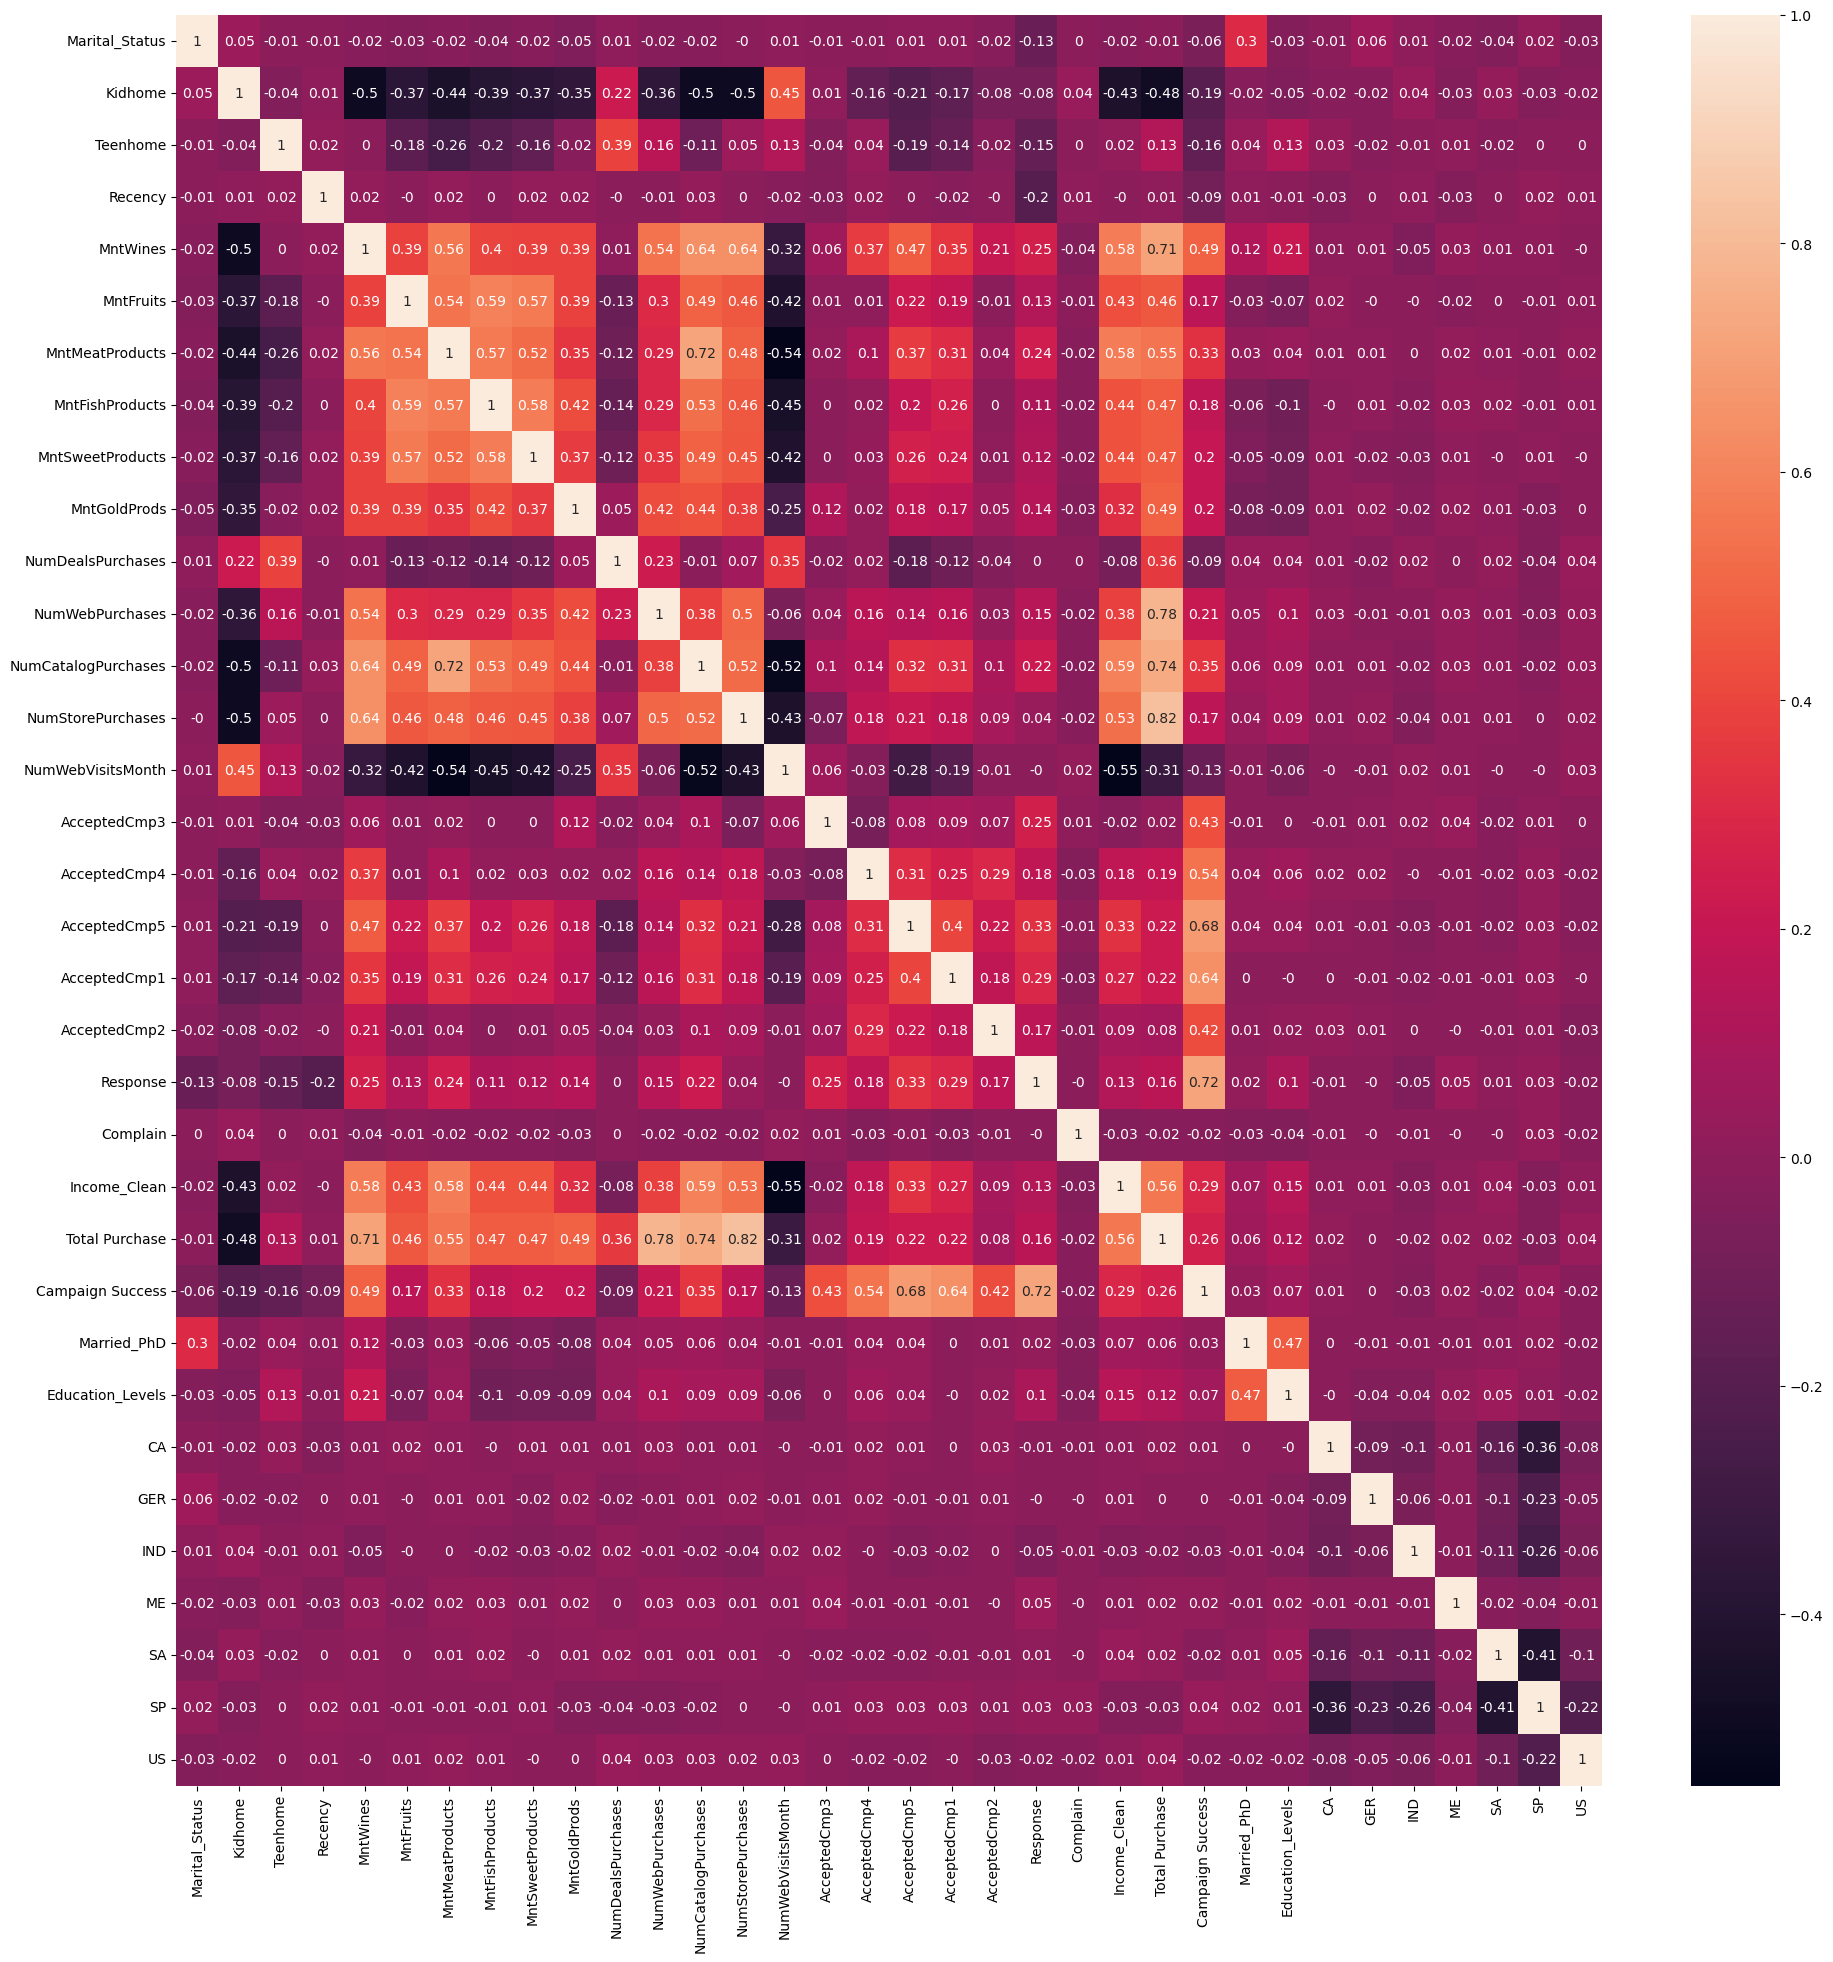

In [23]:
irrelavant = ['Year_Birth','ln_MntFruits','ln_MntFishProducts', 'ln_MntMeatProducts', 'ln_MntSweetProducts','ln_MntGoldProds']
plt.figure(figsize=(23,23))
sns.heatmap(data= m_data.drop(columns = [a for a in irrelavant]).corr(method = 'pearson', numeric_only = 'int').round(2),annot=True, fmt= '.2g') 

#### Correlation Analysis 
1. A positive correlation is visible between Total Purchase and sales of different products.
2. Income also positively correlated with Total Purchase.
3. Wine purchase shows a positive trend with Education levels.
4. Higher income people have accepted offers from more campaigns. This is evident from the correlation between Income_clean and Campaign_Success. However, only 30% of the data shows this trend.
5. Most of sales and purchase have negative correalation with Kidshome, except deals. Higher the number of kids, lesser prefer to purchase without any deals.
6. More people are prefer to buy gold through Catalog compared to Web and In store based on their purchase amount.

In [24]:
def campaign_success(a,b):
    m_data[a+b] = m_data[a]*m_data[b]
    return m_data[a+b]
campaign_success('Campaign Success','CA')
campaign_success('Campaign Success','GER')
campaign_success('Campaign Success','IND')
campaign_success('Campaign Success','ME')
campaign_success('Campaign Success','SA')
campaign_success('Campaign Success','SP')
campaign_success('Campaign Success','US')

ID
737      0
3174     0
5536     0
1103     0
5547     0
        ..
9553     0
9617     0
9960     0
10241    0
10364    0
Name: Campaign SuccessUS, Length: 2240, dtype: int64

In [25]:
m_model_base = m_data.drop(columns = ['Year_Birth', 'Education','Country','Dt_Customer'])

## 2) Statistical Analysis and Model Building

#### Checking for Multicollinearity in Base Model

In [26]:
# Multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor
var = m_model_base
vif = pd.DataFrame()   #Blank Dataframe
vif['Variables'] = m_model_base.columns #Creation of a column with the values as column name.
vif['VIF_Factor'] = [variance_inflation_factor(m_model_base.values,i) for i in range(m_model_base.shape[1])]
print(vif[vif['VIF_Factor']>5])

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


              Variables  VIF_Factor
0        Marital_Status   21.340606
4              MntWines    6.219045
5             MntFruits    5.273678
6       MntMeatProducts    7.672195
7       MntFishProducts    5.400187
8      MntSweetProducts    5.195502
9          MntGoldProds    5.780074
10    NumDealsPurchases         inf
11      NumWebPurchases         inf
12  NumCatalogPurchases         inf
13    NumStorePurchases         inf
14    NumWebVisitsMonth   11.300449
15         AcceptedCmp3         inf
16         AcceptedCmp4         inf
17         AcceptedCmp5         inf
18         AcceptedCmp1         inf
19         AcceptedCmp2         inf
20             Response         inf
22         Income_Clean   11.470003
23         ln_MntFruits   15.561307
24   ln_MntFishProducts   15.951255
25   ln_MntMeatProducts   80.925475
26  ln_MntSweetProducts   14.753346
27      ln_MntGoldProds   30.323514
28       Total Purchase         inf
29     Campaign Success         inf
31     Education_Levels   10

The above VIF factors indicate that some KPI's have positive infinity VIF due to perfect multicollinearity. During regression analysis treating those variables is essential for better model accuracy.

#### Model - 1(Factors influence the store purchases):

In [27]:
Model_1= m_model_base.drop(columns = ['Total Purchase','Campaign Success','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds'])               

In [28]:
# Multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor
var_2 = Model_1
vif_2 = pd.DataFrame()   #Blank Dataframe
vif_2['Variables'] = Model_1.columns #Creation of a column with the values as column name.
vif_2['VIF_Factor'] = [variance_inflation_factor(Model_1.values,i) for i in range(Model_1.shape[1])]
vif_2[vif_2['VIF_Factor']>10]

,Variables,VIF_Factor
0,Marital_Status,20.264953
7,NumStorePurchases,10.250934
8,NumWebVisitsMonth,10.777047
16,Income_Clean,11.314155
19,ln_MntMeatProducts,47.085737
21,ln_MntGoldProds,13.434379
36,Campaign SuccessSP,12.257766


In [29]:
Y = Model_1['NumStorePurchases']

In [30]:
X = Model_1.drop(columns= ['NumStorePurchases'])

In [31]:
import statsmodels.api as sm
X_Constant = sm.add_constant(X)
Model1_OLS = sm.OLS(Y,X_Constant).fit()
print(Model1_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:      NumStorePurchases   R-squared:                       0.593
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     86.84
Date:                Thu, 27 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:56:56   Log-Likelihood:                -4811.0
No. Observations:                2240   AIC:                             9698.
Df Residuals:                    2202   BIC:                             9915.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.7317    

A strong multicollinearity problem exists in the model. Hence, Ridge Regression can be considered to treat the multicollinearity problem.

The above regression models shows the major factors that affects the Number of Store Purchases  with 95% significance levels are 'NumDealsPurchases', 'Kidhome','Teenhome', 'Recency','NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth', 'AcceptedCmp4'  'AcceptedCmp2', 'Response', 'ln_MntFruits, 'ln_MntMeatProducts   'ln_MntSweetProduct', 'Education_Level', 'SP', 'Campaign SuccessIN    'Campaign Successand Recency.cy, 

#### Ridge Regression due to High Multicollinearity

In [32]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state = 42)
sc = StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, Y_train)
print(f"Optimized Test R^2: {ridge_cv.score(X_test_scaled, Y_test):.5f}")
print(f"Optimized Test R^2: {ridge_cv.score(X_train_scaled, Y_train):.5f}")
print(ridge_cv.alpha_)

Optimized Test R^2: 0.58818
Optimized Test R^2: 0.58295
100.0


#### Predictive Power of the model via Standard Machine Learning Method

In [33]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state = 42)
sc = StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
lr = LinearRegression()
lr.fit(X_train_scaled,Y_train)
print(f"Train R^2: {lr.score(X_train_scaled,Y_train):.5f}")
print(f"Test R^2: {lr.score(X_test_scaled,Y_test):.5f}")

Train R^2: 0.58522
Test R^2: 0.59253


### Model 2: (Does US is better in total purchases than R.O.W?)

#### Preliminary Analysis

In [34]:
m_data.groupby(by = ['Country'])['Total Purchase'].sum()

Country
AUS     2314
CA      4101
GER     1788
IND     2099
ME        59
SA      5117
SP     16052
US      1761
Name: Total Purchase, dtype: int64

Preliminary Analysis suggests Spain has the highest purchase among the other countries. US positioned at 6th level.

In [35]:
Model_2= m_model_base.drop(columns = ['Campaign Success','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds',
                                     'NumStorePurchases','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','CA', 'GER', 'IND', 'ME', 'SA', 'SP'])               

In [36]:
vif = pd.DataFrame()
vif['Variables'] = Model_2.columns
vif['VIF Factor'] = [variance_inflation_factor(Model_2.values,i) for i in range(Model_2.shape[1])]
vif[vif['VIF Factor']>10]

,Variables,VIF Factor
0,Marital_Status,17.867079
12,Income_Clean,10.904445
15,ln_MntMeatProducts,45.684088
17,ln_MntGoldProds,13.201284
18,Total Purchase,16.754260
27,Campaign SuccessSP,10.477651


In [37]:
Y = Model_2['Total Purchase']

In [38]:
X = Model_2.drop(columns = 'Total Purchase')
X.head(3)

,Marital_Status,Kidhome,Teenhome,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,...,Married_PhD,Education_Levels,US,Campaign SuccessCA,Campaign SuccessGER,Campaign SuccessIND,Campaign SuccessME,Campaign SuccessSA,Campaign SuccessSP,Campaign SuccessUS
ID,,,,,,,,,,,,,,,,,,,,,
737,7,0,0,56,2,0,1,1,1,0,...,1,4,0,0,0,0,0,0,3,0
3174,6,0,1,61,6,0,1,1,1,1,...,0,2,0,0,0,0,0,0,5,0
5536,6,0,1,61,6,0,1,1,1,1,...,0,2,0,5,0,0,0,0,0,0


In [39]:
import statsmodels.api as sm
X_Constant = sm.add_constant(X)
Model2_OLS = sm.OLS(Y,X_Constant).fit()
print(Model2_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:         Total Purchase   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     211.5
Date:                Thu, 27 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:56:59   Log-Likelihood:                -6285.0
No. Observations:                2240   AIC:                         1.263e+04
Df Residuals:                    2211   BIC:                         1.279e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -7.3151    

The above analysis implies US has no impact on Total Purchases compared to rest of the world. The coefficient implies a very minor positive impact of a person located in US on Total Purchase but it is insignificant.

#### Ridge Regression due to High Multicollinearity

In [40]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state = 42)
sc = StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, Y_train)
print(f"Optimized Test R^2: {ridge_cv.score(X_test_scaled, Y_test):.5f}")
print(f"Optimized Test R^2: {ridge_cv.score(X_train_scaled, Y_train):.5f}")
print("Best Alpha",ridge_cv.alpha_)

Optimized Test R^2: 0.71199
Optimized Test R^2: 0.73185
Best Alpha 0.01


#### Predictive Power of the model via Standard Machine Learning Method

In [41]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state = 42)
sc = StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
lr = LinearRegression()
lr.fit(X_train_scaled,Y_train)
print(f"Train R^2: {lr.score(X_train_scaled,Y_train):.5f}")
print(f"Test R^2: {lr.score(X_test_scaled,Y_test):.5f}")

Train R^2: 0.73185
Test R^2: 0.71199


### Does higher gold sales positively impact in-store purchases?

Yes, higher gold sales positively impact the instore purchases which is evident from Model 1. However, the coefficient is not statistically significant at 95% confidence level.

#### Model 3: Factors affecting the Fish Sale

In [42]:
Model_3= m_model_base.drop(columns = ['Campaign Success','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds',
                                     'Total Purchase',])   

In [43]:
vif = pd.DataFrame()
vif['Variables'] = Model_3.columns
vif['VIF Factor'] = [variance_inflation_factor(Model_3.values,i) for i in range(Model_3.shape[1])]
vif[vif['VIF Factor']>10]

,Variables,VIF Factor
0,Marital_Status,20.264953
7,NumStorePurchases,10.250934
8,NumWebVisitsMonth,10.777047
16,Income_Clean,11.314155
19,ln_MntMeatProducts,47.085737
21,ln_MntGoldProds,13.434379
36,Campaign SuccessSP,12.257766


In [44]:
Y = Model_3['ln_MntFishProducts']
X = Model_3.drop(columns= 'ln_MntFishProducts')

In [45]:
X_constants = sm.add_constant(X)
Model3_OLS = sm.OLS(Y,X_constants).fit()
print(Model3_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:     ln_MntFishProducts   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     109.2
Date:                Thu, 27 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:57:03   Log-Likelihood:                -3142.2
No. Observations:                2240   AIC:                             6360.
Df Residuals:                    2202   BIC:                             6578.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.8293    

Married PhD candidate shows negative impact on the Fish purchase. However, it is insignificant at 95% confidence interval. The sigificant variables which impacts the fish purchase are 'Teenhome', 'NumWebVisitsMonth', 'AcceptedCmp1', 'ln_MntFruits', 'ln_MntMeatProducts', 'ln_MntSweetProducts'  'ln_MntGoldProd and , 'Education_Level. Furthermore, Ridge regression should be preferable due to high multicollinearity.s'

#### Ridge Regression due to High Multicollinearity

In [46]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state = 42)
sc = StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, Y_train)
print(f"Optimized Test R^2: {ridge_cv.score(X_train_scaled, Y_train):.5f}")
print(f"Optimized Test R^2: {ridge_cv.score(X_test_scaled, Y_test):.5f}")
print("Best Alpha",ridge_cv.alpha_)

Optimized Test R^2: 0.64560
Optimized Test R^2: 0.63749
Best Alpha 100.0


#### Predictive Power of the model via Standard Machine Learning Method

In [47]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state = 42)
sc = StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
lr = LinearRegression()
lr.fit(X_train_scaled,Y_train)
print(f"Train R^2: {lr.score(X_train_scaled,Y_train):.5f}")
print(f"Test R^2: {lr.score(X_test_scaled,Y_test):.5f}")

Train R^2: 0.64666
Test R^2: 0.63882


### Model 4: Effectiveness of the campaigns across geography

In [48]:
Model_4= m_model_base.drop(columns = ['AcceptedCmp3','AcceptedCmp2','AcceptedCmp1','AcceptedCmp4','AcceptedCmp5','Response','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds',
                                      'NumDealsPurchases','NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases'])

In [49]:
vif = pd.DataFrame()
vif['Variables'] = Model_4.columns
vif['VIF Factor'] = [variance_inflation_factor(Model_4.values,i) for i in range(Model_4.shape[1])]
vif[vif['VIF Factor']>10]

,Variables,VIF Factor
0,Marital_Status,19.451087
6,Income_Clean,10.846709
9,ln_MntMeatProducts,45.550676
11,ln_MntGoldProds,12.853971
12,Total Purchase,16.587065
13,Campaign Success,19.890143
28,Campaign SuccessSP,11.918874


In [50]:
Y = Model_4['Total Purchase']


In [51]:
X = Model_4.drop(columns = 'Total Purchase')


In [52]:
X_constant = sm.add_constant(X)
Model4_OLS = sm.OLS(Y,X_constant).fit()
print(Model4_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:         Total Purchase   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     199.4
Date:                Thu, 27 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:57:05   Log-Likelihood:                -6303.9
No. Observations:                2240   AIC:                         1.267e+04
Df Residuals:                    2210   BIC:                         1.284e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -7.3834    

The above regression results suggests that the increase in campaigns acceptance could able to drive the total purchase level across different countries relative to baseline. However, in Mexico there is a positive relationship at 81% level of significance. But it does not vary with geographical levels. Also, the increase in campaign acceptance does increase the purchase level, however it is not significant.

#### Ridge Regression due to High Multicollinearity

In [53]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state = 42)
sc = StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, Y_train)
print(f"Optimized Train R^2: {ridge_cv.score(X_train_scaled, Y_train):.5f}")
print(f"Optimized Test R^2: {ridge_cv.score(X_test_scaled, Y_test):.5f}")
print("Best Alpha",ridge_cv.alpha_)

Optimized Train R^2: 0.72761
Optimized Test R^2: 0.70558
Best Alpha 0.01


#### Predictive Power of the model via Standard Machine Learning Method

In [54]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state = 42)
sc = StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
lr = LinearRegression()
lr.fit(X_train_scaled,Y_train)
print(f"Train R^2: {lr.score(X_train_scaled,Y_train):.5f}")
print(f"Test R^2: {lr.score(X_test_scaled,Y_test):.5f}")

Train R^2: 0.72761
Test R^2: 0.70557


## 3) Data Visualization

### 3.1) Which marketing campaign is most successful?

In [55]:
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
sum = [m_data[m_data[sums]==1]['Total Purchase'].sum() for sums in campaign_cols]

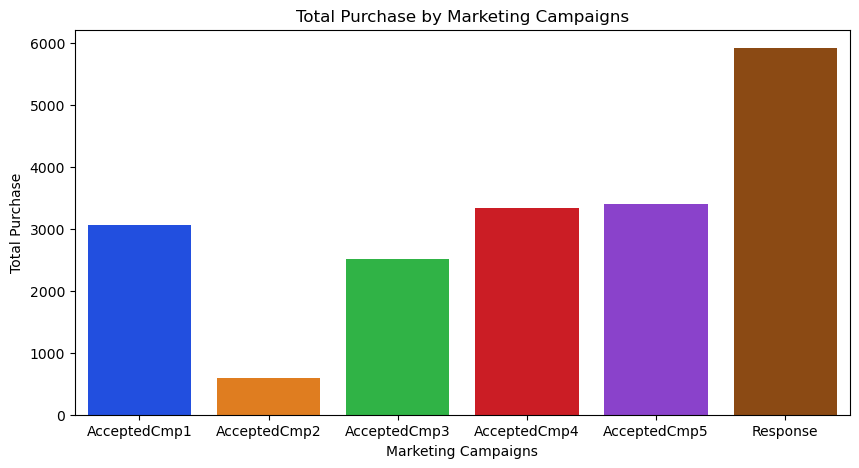

In [56]:
plt.figure(figsize=(10,5))
plt.title("Total Purchase by Marketing Campaigns")
sns.barplot(x = campaign_cols, y=sum, hue = campaign_cols, legend = False, estimator= 'sum',palette= 'bright')
plt.xlabel("Marketing Campaigns")
plt.ylabel("Total Purchase")
plt.savefig('Images/Column_Chart_1.png')

The above column chart signifies Response is the most effective campaign that drive the maximum sales.

### 3.2) What does the average customer look like for this company?

In [57]:
m_data.mean(numeric_only = True)

Year_Birth              1968.805804
Marital_Status             5.845982
Kidhome                    0.444196
Teenhome                   0.506250
Recency                   49.109375
MntWines                 303.935714
MntFruits                 26.302232
MntMeatProducts          166.950000
MntFishProducts           37.525446
MntSweetProducts          27.062946
MntGoldProds              44.021875
NumDealsPurchases          2.325000
NumWebPurchases            4.084821
NumCatalogPurchases        2.662054
NumStorePurchases          5.790179
NumWebVisitsMonth          5.316518
AcceptedCmp3               0.072768
AcceptedCmp4               0.074554
AcceptedCmp5               0.072768
AcceptedCmp1               0.064286
AcceptedCmp2               0.013393
Response                   0.149107
Complain                   0.009375
Income_Clean           52237.975446
ln_MntFruits               2.238966
ln_MntFishProducts         2.534820
ln_MntMeatProducts         4.126719
ln_MntSweetProducts        2

The average customer's profile are:  Year_Birth= 1969-1970; Income: ~52000; Total Purchase: ~15; Wine Amount: 303; Education: Masters; Fruit Amount: 26; Meat Amount: 167; Fish Amount: 38; Sweet Amount: 27; Gold Amount: 44; Number of Kids: ~1

## 3.3) Which products are performing best?

In [58]:
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts','MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
total_sales = [m_data[product].sum() for product in product_cols]

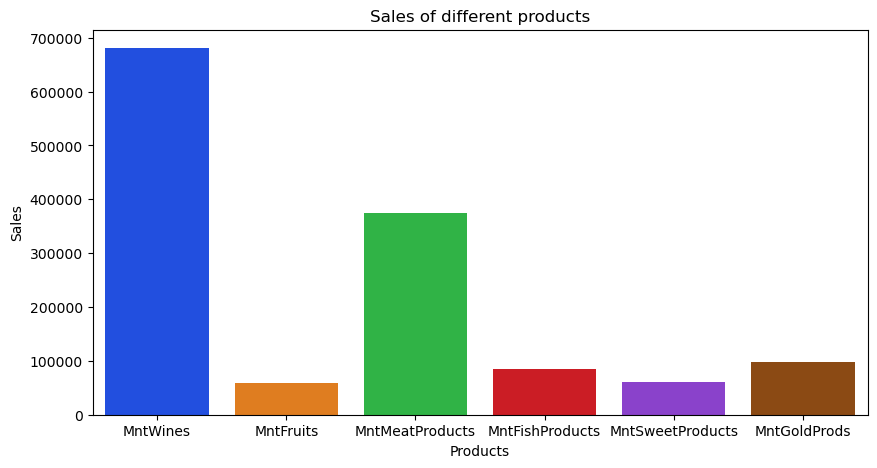

In [59]:
plt.figure(figsize = (10,5))
plt.title("Sales of different products")
sns.barplot(x=product_cols, hue = product_cols, legend = False, y=total_sales,palette= 'bright')
plt.xlabel("Products")
plt.ylabel("Sales")
plt.savefig('Images/Column_Chart_2.png')

Wines and Meat are performaing best compared to other products.

## 3.3) Which channels are underperforming?

In [60]:
channel_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases','NumStorePurchases']
no_prod = [m_data[channel].sum() for channel in channel_cols]

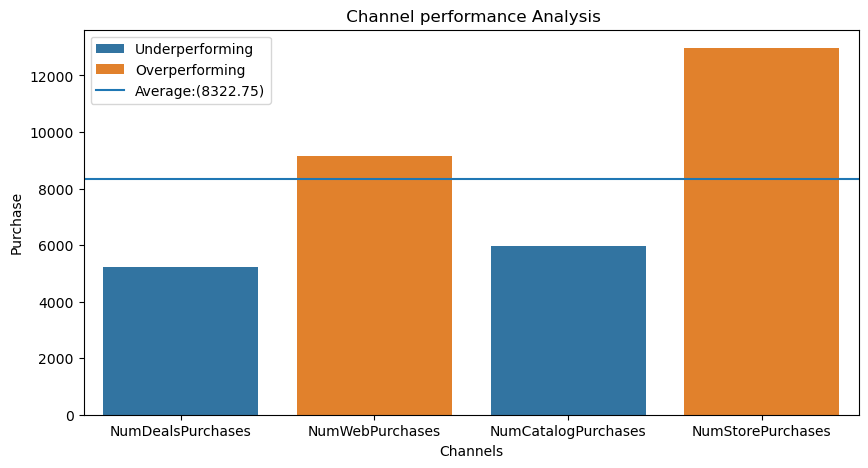

In [62]:
average = np.mean(no_prod)
plt.figure(figsize = (10,5))
plt.title(" Channel performance Analysis")
performance = np.where(no_prod<average,'Underperforming','Overperforming')
sns.barplot(x=channel_cols, y=no_prod, hue = performance)
line = plt.axhline(y=average, label=f"Average:({average})")
plt.xlabel("Channels")
plt.ylabel("Purchase")
plt.legend()
plt.savefig('Images/Column_Chart_3.png')

Deals and Catalogs are underperforming compared to the average units solds across channels